In [1]:
from openpmd_viewer import OpenPMDTimeSeries
import numpy as np
import matplotlib.pyplot as plt
from openpmd_viewer import ParticleTracker

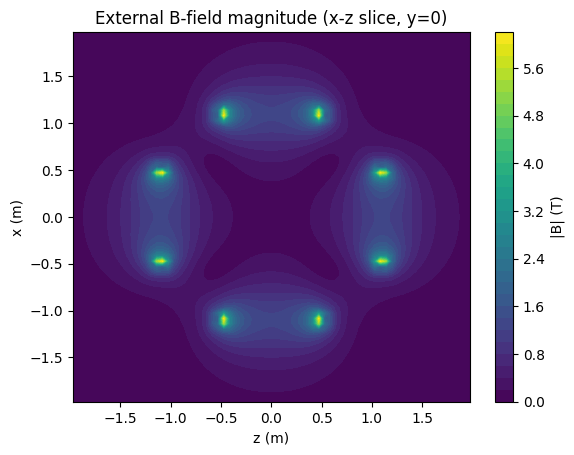

In [3]:
diag_dir = "/Users/yoonseongroh/PycharmProjects/WarpX/inputs/diags/field_diag"
series = OpenPMDTimeSeries(diag_dir)
iterations = series.iterations

_diag_dir = "/Users/yoonseongroh/PycharmProjects/WarpX/inputs/diags/part_diag"
_series = OpenPMDTimeSeries(_diag_dir)

it = iterations[-1]

# External (injected) fields — stored separately from the self-consistent EM field
Bx, info = series.get_field('B', coord='x', iteration=it, slice_across='y')
By, info = series.get_field('B', coord='y', iteration=it, slice_across='y')
Bz, info = series.get_field('B', coord='z', iteration=it, slice_across='y')


B = np.sqrt(Bx**2 + By**2 + Bz**2)

x,y,z = _series.get_particle(['x','y','z'], iteration=it, species="plasma_i")

plt.figure()
plt.contourf(info.z, info.x, B, levels=30, cmap='viridis')
#plt.scatter(z,x)
plt.colorbar(label='|B| (T)')
plt.xlabel('z (m)')
plt.ylabel('x (m)')
plt.title('External B-field magnitude (x-z slice, y=0)')
plt.show()

In [3]:
# Open the time series
series = OpenPMDTimeSeries("/Users/yoonseongroh/PycharmProjects/WarpX/inputs/diags/part_diag")
iterations = series.iterations
pt = ParticleTracker( series, iteration=iterations[-1], select={'z':[-3,3], 'x':[-3, 3]}, species='plasma_i', preserve_particle_index=True)
N_particles = pt.N_selected
N_iterations = len(iterations)

x_trajectories =  np.empty( ( N_iterations, N_particles ) )
z_trajectories = np.empty( ( N_iterations, N_particles ) )
for i, it in enumerate( iterations ):
    x, z = series.get_particle( ['x', 'z'], select=pt, iteration=it, species='plasma_i' )
    x_trajectories[i, :] = x[:]
    z_trajectories[i, :] = z[:]


plt.plot(z_trajectories, x_trajectories)
plt.show()



/opt/homebrew/anaconda3/envs/warpx/lib/python3.14/site-packages/openpmd_viewer/openpmd_timeseries/numba_wrapper.py:24: UserWarning: 
One of the functions called by openPMD-viewer (extract_indices)
could have been faster if `numba` had been installed.
Please consider installing `numba` (e.g. `pip install numba`)
  warnings.warn(


KeyboardInterrupt: 